<div style="background:#5D6D7E;padding:20px;color:#ffffff;margin-top:10px;">

# NLP - Portafolio de Ejercicios 1

## Profesora: Lisibonny Beato
### Período 3-2025-2026</div>


In [22]:
# Importando algunas librerias
%pip install matplotlib seaborn nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('nps_chat')
nltk.download('opinion_lexicon')
nltk.data.find('corpora/nps_chat')

from nltk.corpus import nps_chat, wordnet 


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\alvar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
[nltk_data] Downloading package nps_chat to
[nltk_data]     C:\Users\alvar\AppData\Roaming\nltk_data...
[nltk_data]   Package nps_chat is already up-to-date!
[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     C:\Users\alvar\AppData\Roaming\nltk_data...


Note: you may need to restart the kernel to use updated packages.


[nltk_data]   Unzipping corpora\opinion_lexicon.zip.


## 1. Recolección de datos
### Puntuación máxima de la tarea: 1

Investigue en detalle sobre el corpus nps_chat de NLTK. Elija un archivo de dicho corpus para trabajar los siguientes puntos y explique en detalle lo que contiene y el motivo de su elección. 

In [8]:
# Archivo elegido del corpus
archivo_elegido = '10-19-20s_706posts.xml'

posts = nps_chat.posts(archivo_elegido)
textos = [' '.join(post) for post in posts]

datos_chat = pd.DataFrame({'archivo': archivo_elegido, 'texto': textos})


In [9]:
datos_chat.head()

,archivo,texto
0,10-19-20s_706posts.xml,now im left with this gay name
1,10-19-20s_706posts.xml,:P
2,10-19-20s_706posts.xml,PART
3,10-19-20s_706posts.xml,hey everyone
4,10-19-20s_706posts.xml,ah well


<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">
nps_chat tiene mensajes anonimizados de salas de chat en ingles. Cada archivo agrupa conversaciones por fecha y rango de edad de los participantes. Elegi ese archivo porque representa usuarios en sus 20s y contiene una cantidad amplia de publicaciones, por lo que es una muestra interesante para analizar lenguaje de un joven como abreviaciones expresiones especificas y sus patrones de conversacion.
</div>

## 2. Descripción y exploración de datos
### Puntuación máxima de la tarea: 1

Utilizando pandas realice distintas descriptivas y exploraciones sobre los textos y comente acerca de sus hallazgos

In [10]:
# Copia del conjunto para explorar sin modificar el original
exploracion = datos_chat.copy()

# Variables sencillas para describir cada mensaje
exploracion['cont_palabras'] = exploracion['texto'].str.split().str.len()
exploracion['cont_caracteres'] = exploracion['texto'].str.len()
exploracion['es_mensaje_sistema'] = exploracion['texto'].isin(['JOIN', 'PART'])

In [11]:
# Primeras filas del conjunto explorado
display(exploracion.head())

,archivo,texto,cont_palabras,cont_caracteres,es_mensaje_sistema
0,10-19-20s_706posts.xml,now im left with this gay name,7,30,False
1,10-19-20s_706posts.xml,:P,1,2,False
2,10-19-20s_706posts.xml,PART,1,4,True
3,10-19-20s_706posts.xml,hey everyone,2,12,False
4,10-19-20s_706posts.xml,ah well,2,7,False


In [12]:
# Resumen general del archivo elegido
resumen = pd.DataFrame({
    'total_mensajes': [len(exploracion)],
    'promedio_palabras': [exploracion['cont_palabras'].mean()],
    'mensaje_mas_corto': [exploracion['cont_palabras'].min()],
    'mensaje_mas_largo': [exploracion['cont_palabras'].max()],
    'mensajes_sistema': [exploracion['es_mensaje_sistema'].sum()]
})

display(resumen)

,total_mensajes,promedio_palabras,mensaje_mas_corto,mensaje_mas_largo,mensajes_sistema
0,706,4.012748,1,34,125


In [13]:
# Mensajes mas largos para ver ejemplos del contenido
display(exploracion.sort_values('cont_palabras', ascending=False).head(10))

,archivo,texto,cont_palabras,cont_caracteres,es_mensaje_sistema
631,10-19-20s_706posts.xml,". ACTION walks up to U30 , runs their fingers ...",34,154,False
51,10-19-20s_706posts.xml,I am too .. Connected to ... Slip away ... Fad...,31,151,False
196,10-19-20s_706posts.xml,Finger .. Deep within the borderline .. Show m...,31,145,False
423,10-19-20s_706posts.xml,You can pick your friends .. And you can pick ...,23,99,False
291,10-19-20s_706posts.xml,. ACTION Now Playing - Cradle of Filth - A Got...,22,96,False
668,10-19-20s_706posts.xml,very bored any guys wana chat to a chik from a...,18,75,False
152,10-19-20s_706posts.xml,. ACTION would lol @ U121 . . . but appearentl...,17,72,False
123,10-19-20s_706posts.xml,"i do n't want hot pics of a female , I can loo...",17,61,False
176,10-19-20s_706posts.xml,U136 .. get the hell in my freaking PM box .. ...,16,70,False
162,10-19-20s_706posts.xml,U136 .. get the hell outta my freaking PM box ...,16,83,False


In [14]:
# Palabras mas frecuentes, quitando algunas palabras muy comunes
stopwords_basicas = ['join','?',"'s",'!','..','part',',','the', 'a', 'to', 'i', 'you', 'and', 'is', 'in', 'it', 'of', 'me', 'my', 'for','.']
palabras = exploracion['texto'].str.lower().str.split().explode()
palabras = palabras[~palabras.isin(stopwords_basicas)]

display(palabras.value_counts().head(15))

texto
action    44
lol       36
u         26
u115      24
u121      23
...       23
that      22
u6        21
u7        17
do        16
any       16
/         14
your      14
what      14
he        14
Name: count, dtype: int64

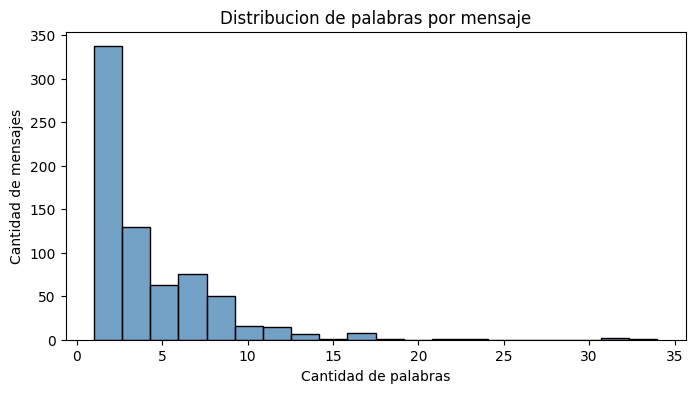

In [15]:
# Distribucion de la longitud de los mensajes
plt.figure(figsize=(8, 4))
sns.histplot(exploracion['cont_palabras'], bins=20, color='steelblue')
plt.title('Distribucion de palabras por mensaje')
plt.xlabel('Cantidad de palabras')
plt.ylabel('Cantidad de mensajes')
plt.show()

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">
He notado que los mensajes del chat suelen ser cortos, algo normal en conversaciones de jovenes. Tambien aparecen mensajes como JOIN y PART, que no son frases reales sino eventos del sistema cuando alguien entra o sale del chat. Las palabras frecuentes ayudan a ver el tono del archivo y los mensajes mas largos sirven para identificar ejemplos con mas contexto.
</div>

## 3. Limpieza de datos
### Puntuación máxima de la tarea: 1

Investigue y aplique distintas técnicas de limpieza para el conjunto de textos  y explique las razones de la aplicación de cada una de estas

In [16]:
# Copia para limpiar sin perder los mensajes originales
datos_limpieza = datos_chat.copy()

# Quitamos mensajes del sistema porque no representan conversacion real
datos_limpieza = datos_limpieza[~datos_limpieza['texto'].isin(['JOIN', 'PART'])].copy()
datos_limpieza = datos_limpieza[~datos_limpieza['texto'].str.startswith('NICK')].copy()

display(datos_limpieza.head())

,archivo,texto
0,10-19-20s_706posts.xml,now im left with this gay name
1,10-19-20s_706posts.xml,:P
3,10-19-20s_706posts.xml,hey everyone
4,10-19-20s_706posts.xml,ah well
6,10-19-20s_706posts.xml,U7 is a gay name .


In [17]:
import re

def limpiar_mensaje(texto):
    texto = texto.lower()
    texto = re.sub(r'u\d+', ' ', texto)  # elimina usuarios anonimizados como U115
    texto = re.sub(r'[^a-z\s]', ' ', texto)  # deja solo letras y espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

In [18]:
datos_limpieza['texto_limpio'] = datos_limpieza['texto'].apply(limpiar_mensaje)

# Eliminamos filas que quedaron vacias despues de limpiar simbolos o eventos
datos_limpios = datos_limpieza[datos_limpieza['texto_limpio'] != ''].copy()

datos_limpios[['texto', 'texto_limpio']].head(10)

,texto,texto_limpio
0,now im left with this gay name,now im left with this gay name
1,:P,p
3,hey everyone,hey everyone
4,ah well,ah well
6,U7 is a gay name .,is a gay name
7,. ACTION gives U121 a golf clap .,action gives a golf clap
10,hi U59,hi
11,26 / m / ky women that are nice please pm me,m ky women that are nice please pm me
14,there ya go U7,there ya go
15,do n't golf clap me .,do n t golf clap me


In [19]:
# Comparacion rapida antes y despues de la limpieza
comparacion_limpieza = pd.DataFrame({
    'mensajes_originales': [len(datos_chat)],
    'sin_mensajes_sistema': [len(datos_limpieza)],
    'mensajes_limpios': [len(datos_limpios)],
    'palabras_promedio_limpias': [datos_limpios['texto_limpio'].str.split().str.len().mean()]
})

display(comparacion_limpieza)

,mensajes_originales,sin_mensajes_sistema,mensajes_limpios,palabras_promedio_limpias
0,706,580,559,3.745975


In [20]:
# Palabras mas comunes despues de limpiar
stopwords_limpieza = ['the', 'a', 'to', 'i', 'you', 'and', 'is', 'in', 'it', 'of', 'me', 'my', 'for', 'im']
palabras_limpias = datos_limpios['texto_limpio'].str.split().explode()
palabras_limpias = palabras_limpias[palabras_limpias.str.len() > 1]
palabras_limpias = palabras_limpias[~palabras_limpias.isin(stopwords_limpieza)]

display(palabras_limpias.value_counts().head(15))

texto_limpio
action    44
lol       36
that      22
do        16
any       16
your      14
what      14
he        14
hey       13
hi        13
have      13
not       13
pm        12
wanna     12
lmao      12
Name: count, dtype: int64

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">
Para la limpieza quite primero JOIN, PART y NICK porque son eventos del sistema, no mensajes escritos por personas. Luego converti el texto a minusculas para unificar palabras iguales, elimine usuarios anonimizados como U115 porque no aportan significado, y retire signos o simbolos para concentrarme en las palabras. Esta limpieza es simple, pero deja el conjunto mas claro para contar palabras y buscar emociones sin borrar por completo el estilo informal del chat.
</div>

## 4. Buscando emociones
### Puntuación máxima de la tarea: 3

4.1 Investigue acerca del corpus opinion_lexicon de NLTK y documento la información más relevante encontrada (1 punto)

4.2 Realice una función que usando este corpus identifique  palabras  positivas y negativas que aparecen en los textos. (1 punto)

4.3 Realice funciones que muestren estadísticas y gráficos que ayuden a entender lo que revelan estos textos (Ej. Totales for tipo, palabras más populares por tipo, entre otras) (1 punto)

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">
El corpus opinion_lexicon de NLTK es un lexicon de opinion que contiene dos listas de palabras en ingles: una de palabras positivas y otra de palabras negativas. Fue creado para tareas de mineria de opinion y analisis de sentimiento.
</div>

In [23]:

from nltk.corpus import opinion_lexicon

palabras_positivas = set(opinion_lexicon.positive())
palabras_negativas = set(opinion_lexicon.negative())

pd.DataFrame({
    'tipo': ['positivas', 'negativas'],
    'cantidad_palabras': [len(palabras_positivas), len(palabras_negativas)]
})

,tipo,cantidad_palabras
0,positivas,2006
1,negativas,4783


In [24]:
def identificar_emociones(texto):
    palabras = texto.split()
    positivas = [palabra for palabra in palabras if palabra in palabras_positivas]
    negativas = [palabra for palabra in palabras if palabra in palabras_negativas]
    
    return {
        'palabras_positivas': positivas,
        'palabras_negativas': negativas,
        'total_positivas': len(positivas),
        'total_negativas': len(negativas)
    }

In [25]:
emociones_chat = datos_limpios.copy()
resultado = emociones_chat['texto_limpio'].apply(identificar_emociones).apply(pd.Series)

emociones_chat = pd.concat([emociones_chat, resultado], axis=1)

emociones_chat[['texto_limpio', 'palabras_positivas', 'palabras_negativas', 'total_positivas', 'total_negativas']].head(10)

,texto_limpio,palabras_positivas,palabras_negativas,total_positivas,total_negativas
0,now im left with this gay name,[],[],0,0
1,p,[],[],0,0
3,hey everyone,[],[],0,0
4,ah well,[well],[],1,0
6,is a gay name,[],[],0,0
7,action gives a golf clap,[],[],0,0
10,hi,[],[],0,0
11,m ky women that are nice please pm me,[nice],[],1,0
14,there ya go,[],[],0,0
15,do n t golf clap me,[],[],0,0


In [26]:
def resumen_emociones(datos):
    return pd.DataFrame({
        'mensajes_con_positivas': [(datos['total_positivas'] > 0).sum()],
        'mensajes_con_negativas': [(datos['total_negativas'] > 0).sum()],
        'total_palabras_positivas': [datos['total_positivas'].sum()],
        'total_palabras_negativas': [datos['total_negativas'].sum()]
    })

display(resumen_emociones(emociones_chat))

,mensajes_con_positivas,mensajes_con_negativas,total_palabras_positivas,total_palabras_negativas
0,70,65,78,73


In [39]:
def palabras_mas_usadas(datos, columna, tipo):
    palabras = datos[columna].explode()
    palabras = palabras[palabras.notna()]
    frecuentes = palabras.value_counts().head(10).reset_index()
    frecuentes.columns = ['palabra', 'cantidad']
    frecuentes['tipo'] = tipo
    return frecuentes

top_positivas = palabras_mas_usadas(emociones_chat, 'palabras_positivas', 'positivas')
top_negativas = palabras_mas_usadas(emociones_chat, 'palabras_negativas', 'negativas')

display(pd.concat([top_positivas, top_negativas]))

,palabra,cantidad,tipo
0,good,7,positivas
1,nice,7,positivas
2,hot,7,positivas
3,well,6,positivas
4,like,5,positivas
5,right,5,positivas
6,hug,4,positivas
7,love,4,positivas
8,free,3,positivas
9,work,2,positivas


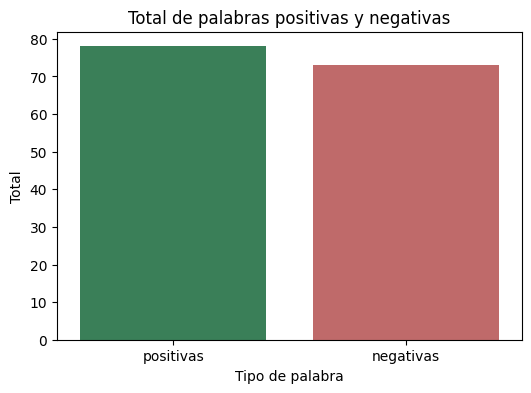

In [27]:
def graficar_totales_emociones(datos):
    totales = pd.DataFrame({
        'tipo': ['positivas', 'negativas'],
        'total': [datos['total_positivas'].sum(), datos['total_negativas'].sum()]
    })
    
    plt.figure(figsize=(6, 4))
    sns.barplot(data=totales, x='tipo', y='total', hue='tipo', palette=['seagreen', 'indianred'], legend=False)
    plt.title('Total de palabras positivas y negativas')
    plt.xlabel('Tipo de palabra')
    plt.ylabel('Total')
    plt.show()

graficar_totales_emociones(emociones_chat)

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">
El análisis con opinion_lexicon muestra que el corpus tiene expresiones positivas y negativas, aunque la mayoria de los mensajes no incluye palabras que este recurso clasifique. En los resultados aparecieron 70 mensajes con palabras positivas y 65 con palabras negativas, para un total de 78 palabras positivas y 73 negativas. O sea que, dentro de esta muestra, la carga emocional esta bastante balanceada. Las palabras positivas más frecuentes fueron good, nice, hot, well y like, y entre las negativas las que más se repitieron fueron f*ck, hate, hell, freaking y spank. Esto refleja el estilo informal del chat: aparecen palabras afectivas, expresiones coloquiales y vocabulario fuerte. Tambien hay una limitación importante: el lexicon clasifica las palabras de forma aislada, así que no siempre capta la ironía, el contexto o los usos ambiguos dentro de la conversacion.
</div>

## 5. Wordnet
### Puntuación máxima de la tarea: 4

5.1. Investigue sobre el corpus Wordnet, disponible en NLTK y documente la información más relevante encontrada. (1 punto)

5.2. Posteriormente, desarrolle una función en Python que reciba  un conjunto de textos y, usando  Wordnet, devuelva en una única estructura de su elección (lista de tuplas, diccionario), los diferentes synsets de cada palabra de acuerdo a la función que ejerce en el texto (sea sustantivo, verbo, adjetivo o adverbio). (2 puntos)

5.3 Pruebe dicha función sobre el conjunto de datos. (1 punto)

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">
WordNet es una base lexica en ingles incluida en NLTK. Organiza las palabras en synsets, que son grupos de sinonimos con un significado parecido. Tambien permite consultar relaciones semanticas como sinonimos, hiperonimos e hiponimos. En este caso sirve para revisar los posibles sentidos de cada palabra segun su funcion en el texto: sustantivo, verbo, adjetivo o adverbio.
</div>

In [28]:
# Recursos necesarios para WordNet y etiquetado gramatical
def asegurar_recurso_nltk(nombre, rutas):
    encontrado = False
    
    for ruta in rutas:
        try:
            nltk.data.find(ruta)
            encontrado = True
        except LookupError:
            pass
    
    if not encontrado:
        nltk.download(nombre, quiet=True)

asegurar_recurso_nltk('wordnet', ['corpora/wordnet', 'corpora/wordnet.zip'])
asegurar_recurso_nltk('averaged_perceptron_tagger_eng', [
    'taggers/averaged_perceptron_tagger_eng',
    'taggers/averaged_perceptron_tagger_eng.zip'
])

In [29]:
import re

def convertir_pos_wordnet(etiqueta):
    if etiqueta.startswith('N'):
        return wordnet.NOUN, 'sustantivo'
    if etiqueta.startswith('V'):
        return wordnet.VERB, 'verbo'
    if etiqueta.startswith('J'):
        return wordnet.ADJ, 'adjetivo'
    if etiqueta.startswith('R'):
        return wordnet.ADV, 'adverbio'
    return None, None

def obtener_synsets_wordnet(textos):
    resultados = {}
    
    for numero, texto in enumerate(textos):
        tokens = re.findall(r'[a-zA-Z]+', texto.lower())
        etiquetas = nltk.pos_tag(tokens)
        resultados[numero] = []
        
        for palabra, etiqueta in etiquetas:
            pos_wordnet, funcion = convertir_pos_wordnet(etiqueta)
            
            if pos_wordnet is not None:
                synsets = wordnet.synsets(palabra, pos=pos_wordnet)
                
                if synsets:
                    resultados[numero].append({
                        'palabra': palabra,
                        'funcion': funcion,
                        'synsets': [synset.name() for synset in synsets]
                    })
    
    return resultados

In [30]:
# Prueba de la funcion sobre el conjunto de datos limpio
synsets_chat = obtener_synsets_wordnet(datos_limpios['texto_limpio'])

muestra_synsets = {
    indice: valores
    for indice, valores in synsets_chat.items()
    if valores
}

list(muestra_synsets.items())[:3]

[(0,
  [{'palabra': 'now',
    'funcion': 'adverbio',
    'synsets': ['now.r.01',
     'nowadays.r.01',
     'now.r.03',
     'now.r.04',
     'immediately.r.01',
     'now.r.06',
     'now.r.07']},
   {'palabra': 'left',
    'funcion': 'verbo',
    'synsets': ['leave.v.01',
     'leave.v.02',
     'leave.v.03',
     'leave.v.04',
     'exit.v.01',
     'leave.v.06',
     'leave.v.07',
     'leave.v.08',
     'entrust.v.02',
     'bequeath.v.01',
     'leave.v.11',
     'leave.v.12',
     'impart.v.01',
     'forget.v.04']},
   {'palabra': 'gay', 'funcion': 'sustantivo', 'synsets': ['homosexual.n.01']},
   {'palabra': 'name',
    'funcion': 'sustantivo',
    'synsets': ['name.n.01',
     'name.n.02',
     'name.n.03',
     'name.n.04',
     'name.n.05',
     'name.n.06']}]),
 (1,
  [{'palabra': 'p',
    'funcion': 'sustantivo',
    'synsets': ['phosphorus.n.01', 'p.n.02']}]),
 (3,
  [{'palabra': 'well',
    'funcion': 'adverbio',
    'synsets': ['well.r.01',
     'well.r.02',
     'wel

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">
Con el ejercicio 5 uno se da cuenta de que WordNet sirve mucho para analizar textos, porque conecta cada palabra con los significados que puede tener segun su funcion gramatical. Al aplicar la funcion al corpus nps_chat, se nota que los mensajes son cortos, informales y llenos de expresiones tipicas de la conversacion digital, asi que usar los synsets (conjuntos de sinonimos que WordNet agrupa por significado) ayuda a entender mejor el vocabulario que aparece. Pero tambien se ve que el contexto importa, porque una misma palabra puede tener varios sentidos y WordNet no siempre escoge el correcto por si solo. Al final, el ejercicio muestra que el procesamiento de lenguaje natural mezcla limpieza, exploración y recursos como WordNet para entender mejor los datos de texto.
</div>